In [1]:
import logging
import math
import time
import random
from pathlib import Path
from collections import namedtuple

import cv2
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from scipy.spatial.transform import Rotation as scipy_R
from skimage import color
from skimage import io
from skimage.transform import rotate, resize
from torch.utils.data import Dataset
from torch.utils.data.dataloader import default_collate
from torchvision import transforms

import cv2
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

from dataset import CamLocDataset

from colmap_util import read_cameras_binary, read_images_binary, read_points3D_binary
from nvm_util import read_nvm_file
from ace_network import Regressor

In [2]:
Options = namedtuple('Options', [
    'scene', 
    'image_resolution',
    'aug_rotation', 
    'aug_scale',
    'mask_method',
    'mask_radius',
    'detector_name',
])
opt = Options(
    scene = Path('datasets/Cambridge_KingsCollege/'),
    image_resolution = 480,
    aug_rotation = 15,
    aug_scale=1.5,
    mask_method='detector',
    mask_radius=3,
    detector_name='superpoint_aachen',
)

dataset = CamLocDataset(
    root_dir= opt.scene / "train",
    mode=0,  # Default for ACE, we don't need scene coordinates/RGB-D.
    # use_half=options.use_half,
    image_height=opt.image_resolution,
    augment=True,
    aug_rotation=opt.aug_rotation,
    aug_scale_max=opt.aug_scale,
    aug_scale_min=1 / opt.aug_scale,
    # num_clusters=options.num_clusters,  # Optional clustering for Cambridge experiments.
    # cluster_idx=options.cluster_idx,    # Optional clustering for Cambridge experiments.
    mask_method=opt.mask_method,
    mask_radius=opt.mask_radius,
    detector_name=opt.detector_name,
)
print(len(dataset))

1220


In [3]:
def resize_mask(mask, H=87, W=154):
    return TF.resize(mask, [H, W], interpolation=TF.InterpolationMode.NEAREST)

torch.Size([1, 87, 154])
torch.Size([1, 87, 154])
torch.Size([1, 87, 154])
torch.Size([1, 87, 154])
torch.Size([1, 87, 154])


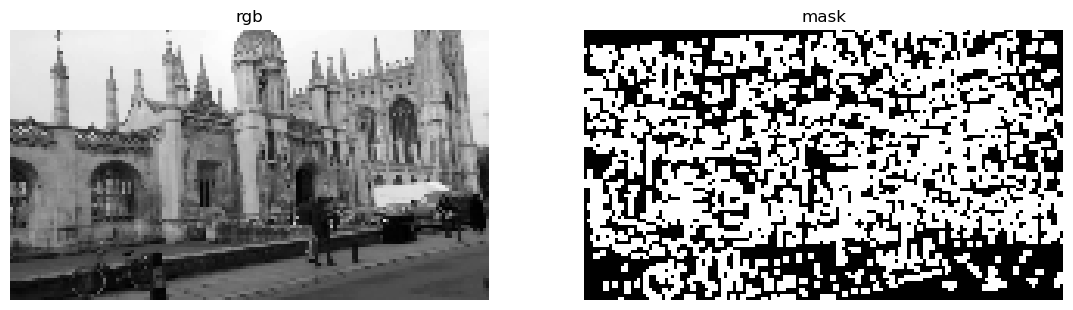

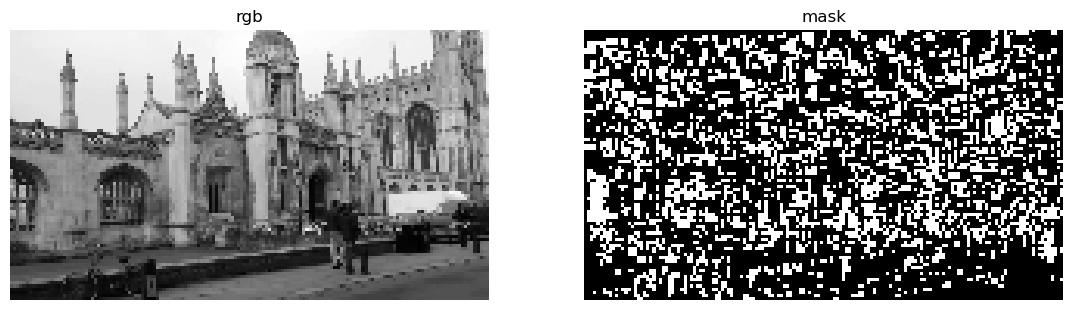

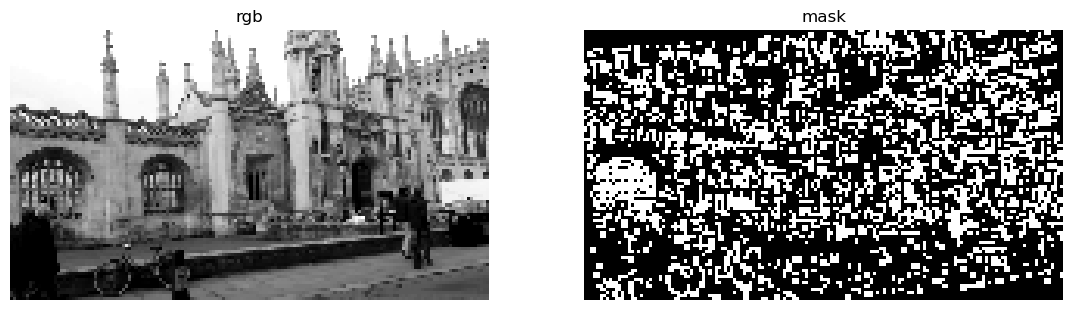

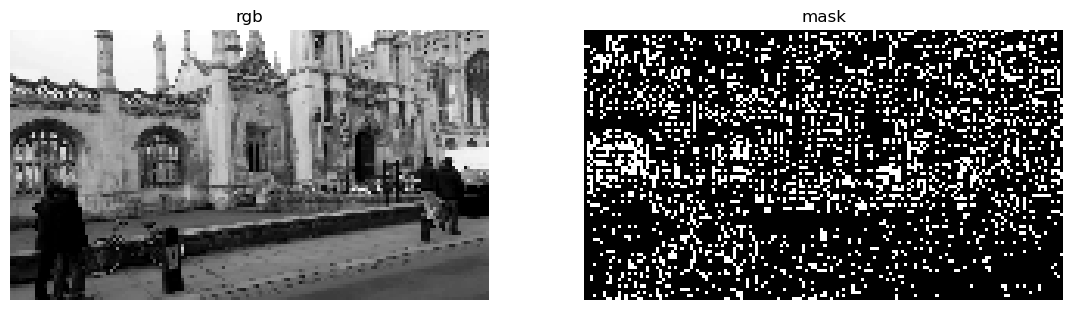

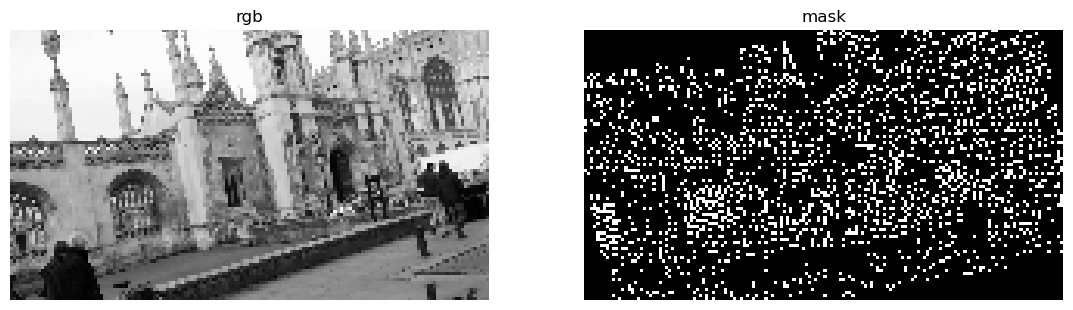

In [4]:
for i in range(60, 65):
    image, image_mask, image_mask_pts2D, \
    pose, pose_inv, \
    K, K_inv, \
    _, _, \
    info = dataset.__getitem__(i)

    # resize image to fit the network input
    image = resize_mask(image)
    image_mask = resize_mask(image_mask)
    image_mask_pts2D = resize_mask(image_mask_pts2D)
    print(image.shape)

    plt.figure(figsize=(21, 7))
    plt.subplot(1, 3, 1)
    plt.axis('off')
    plt.title('rgb')
    plt.imshow(image[0], cmap='gray')

    plt.subplot(1, 3, 2)
    plt.axis('off')
    plt.title('mask')
    plt.imshow(image_mask_pts2D[0], cmap='gray')

    # pts2D = info['pts2D']
    # plt.subplot(1, 3, 3)
    # plt.axis('off')
    # plt.title('pts2D')
    # plt.scatter(pts2D[:, 0].int().numpy(), pts2D[:, 1].int().numpy(), s=1, c='w')
    # plt.imshow(np.zeros_like(image[0]), cmap='gray')

## Viz mask in training buffer

In [4]:
mask = np.load('image_mask.npy')
mask_pts2D = np.load('mask.npy')
print(mask.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'image_mask.npy'

In [ ]:
plt.figure(figsize=(21, 7))
plt.subplot(1, 2, 1)
plt.imshow(mask[0, 0], cmap='gray')  
plt.subplot(1, 2, 2)
plt.imshow(mask_pts2D[0, 0], cmap='gray')  

NameError: name 'plt' is not defined

In [5]:
ft_mask = np.load('../FocusTune/image_mask.npy')
ft_mask_pts2D = np.load('../FocusTune/mask.npy').reshape(1, 1, 87, 154)
print(ft_mask.shape)
print(ft_mask_pts2D.shape)

(1, 1, 87, 154)
(1, 1, 87, 154)


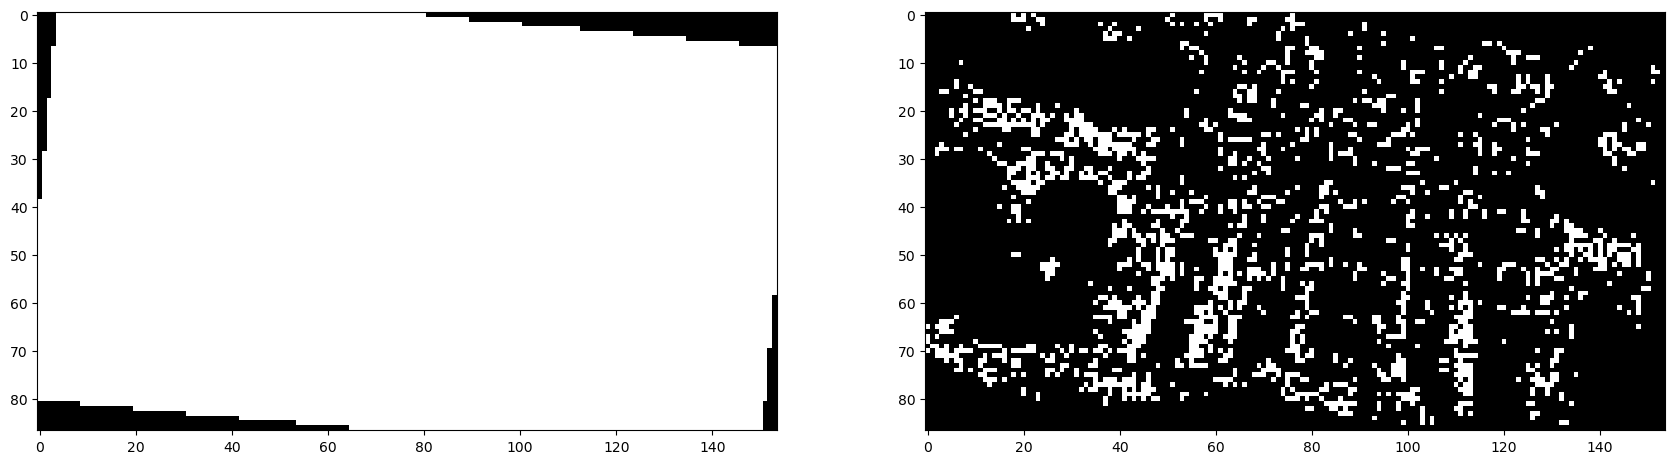

In [42]:

plt.figure(figsize=(21, 7))
plt.subplot(1, 2, 1)
plt.imshow(ft_mask[0, 0], cmap='gray')  
plt.subplot(1, 2, 2)
plt.imshow(ft_mask_pts2D[0, 0], cmap='gray')  

### Viz target mask

In [50]:
tgt_px = np.load('tgt_px_b2HW.npy')
tgt_px_f = np.load('tgt_px_b2F.npy')
sample_idxs = np.load('sample_idxs.npy')

tgt_px = tgt_px.reshape(87, 154, 2)
tgt_px_f = tgt_px_f.reshape(32, 32, 2)
print(tgt_px.shape)
print(tgt_px_f.shape)
print(sample_idxs.shape)
print(sample_idxs.reshape(32, 32)[:10])

plt.figure(figsize=(21, 7))
plt.subplot(1, 2, 1)
plt.imshow(tgt_px[:, :, 0], cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(tgt_px[:, :, 1], cmap='gray')

plt.figure(figsize=(21, 7))
plt.subplot(1, 2, 1)
plt.imshow(tgt_px_f[:, :, 0], cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(tgt_px_f[:, :, 1], cmap='jet')

ValueError: cannot reshape array of size 10240 into shape (87,154,2)

In [60]:
tgt_px_b2 = np.load('tgt_px_b2.npy')
tgt_px_b2.shape, tgt_px_b2

((5120, 2),
 array([[116.,   4.],
        [140.,   4.],
        [180.,   4.],
        ...,
        [580., 364.],
        [588., 364.],
        [604., 364.]], dtype=float32))

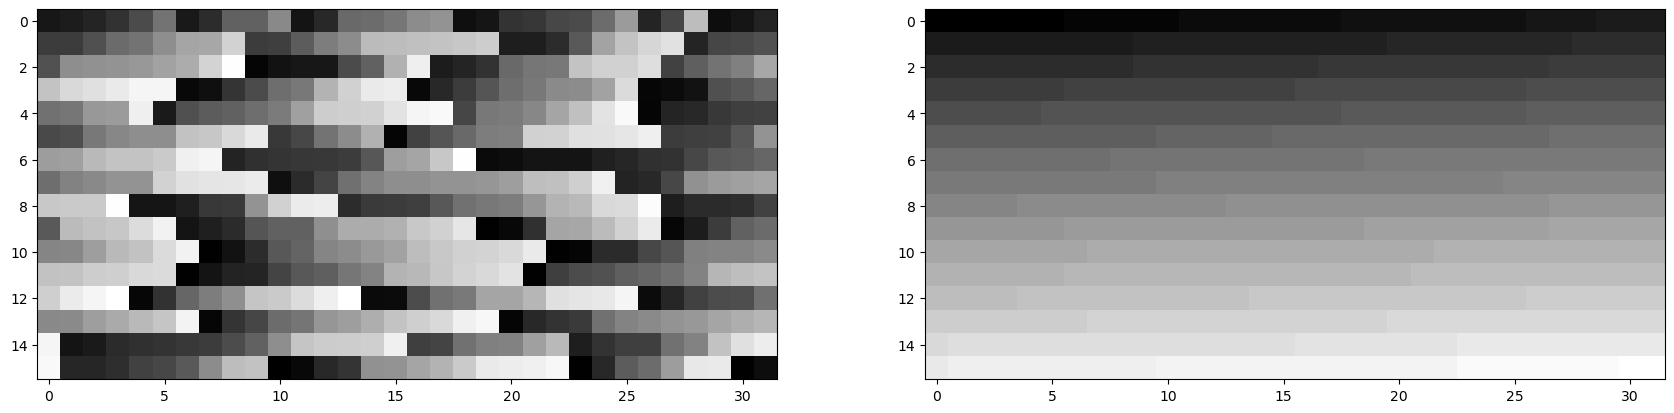

In [67]:
tgt_px = tgt_px_b2.reshape(10, 16, 32, 2)
plt.figure(figsize=(21, 7))
plt.subplot(1, 2, 1)
plt.imshow(tgt_px[0, :, :, 0], cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(tgt_px[0, :, :, 1], cmap='gray')

In [68]:
tgt_px = np.load('tgt_px_b2HW.npy')
tgt_h = np.load('tgt_H_inc_mask_bHW.npy')
tgt_w = np.load('tgt_W_inc_mask_bHW.npy')
tgt_mask = np.load('tgt_inc_mask_bHW.npy')
pred_px = np.load('pred_px_b2HW.npy')
pred_h = np.load('pred_H_inc_mask_bHW.npy')
pred_w = np.load('pred_W_inc_mask_bHW.npy')
pred_mask = np.load('pred_inc_mask_bHW.npy')
rev_mask = np.load('rev_order_mask_bHW.npy')

0.0 1228.0


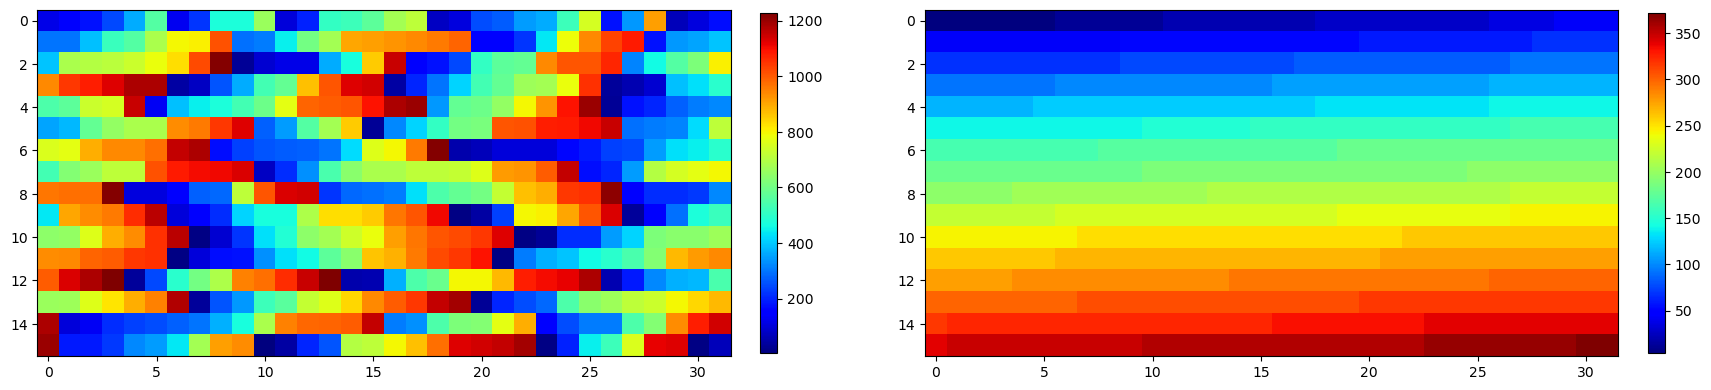

In [69]:
H, W = tgt_px.shape[2:4]
tgt_px_rgb = np.zeros((H, W, 3))
tgt_px_rgb[:, :, 0] = tgt_px[0, 0]
tgt_px_rgb[:, :, 1] = tgt_px[0, 1]
print(tgt_px_rgb.min(), tgt_px_rgb.max())
plt.figure(figsize=(21, 7))
plt.subplot(1, 2, 1)
plt.imshow(tgt_px_rgb[:, :, 0], cmap='jet')
plt.colorbar(fraction=0.046*(H/W), pad=0.04)
plt.subplot(1, 2, 2)
plt.imshow(tgt_px_rgb[:, :, 1], cmap='jet')
plt.colorbar(fraction=0.046*(H/W), pad=0.04)
# plt.imshow(pred_px[0, 0], cmap='gray')

-116.19735717773438 1037.940185546875


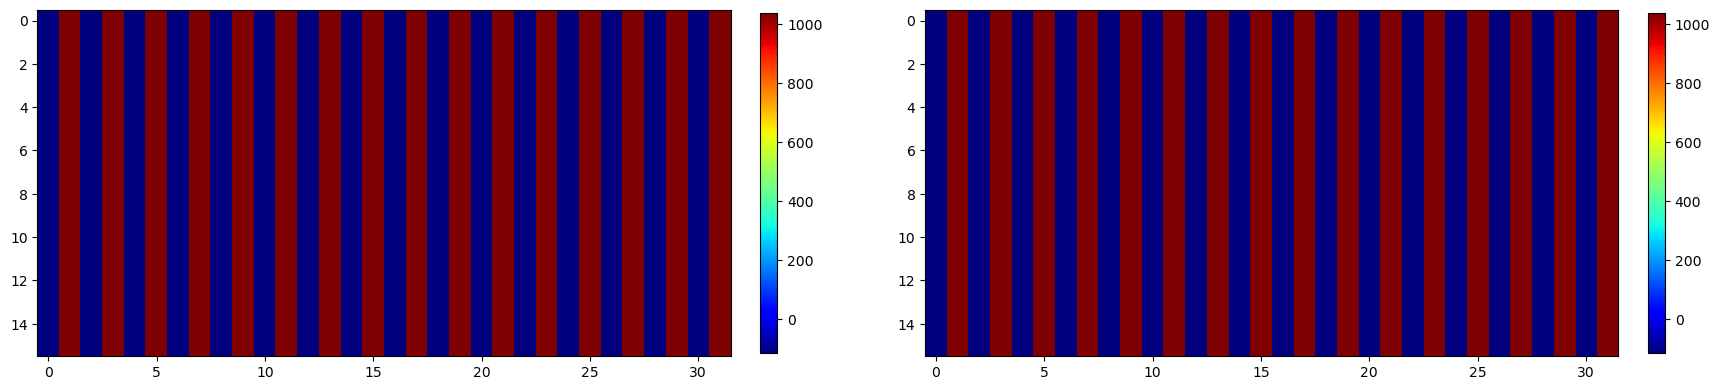

In [70]:
H, W = 16, 32 # pred_px.shape[2:4]
pred_px_rgb = np.zeros((H, W, 3))
pred_px_rgb[:, :, 0] = pred_px[0, 0]
pred_px_rgb[:, :, 1] = pred_px[0, 1]
print(pred_px_rgb.min(), pred_px_rgb.max())
plt.figure(figsize=(21, 7))
plt.subplot(1, 2, 1)
plt.imshow(pred_px_rgb[:, :, 0], cmap='jet')
plt.colorbar(fraction=0.046*(H/W), pad=0.04)
plt.subplot(1, 2, 2)
plt.imshow(pred_px_rgb[:, :, 1], cmap='jet')
plt.colorbar(fraction=0.046*(H/W), pad=0.04)
# plt.imshow(pred_px[0, 0], cmap='gray')

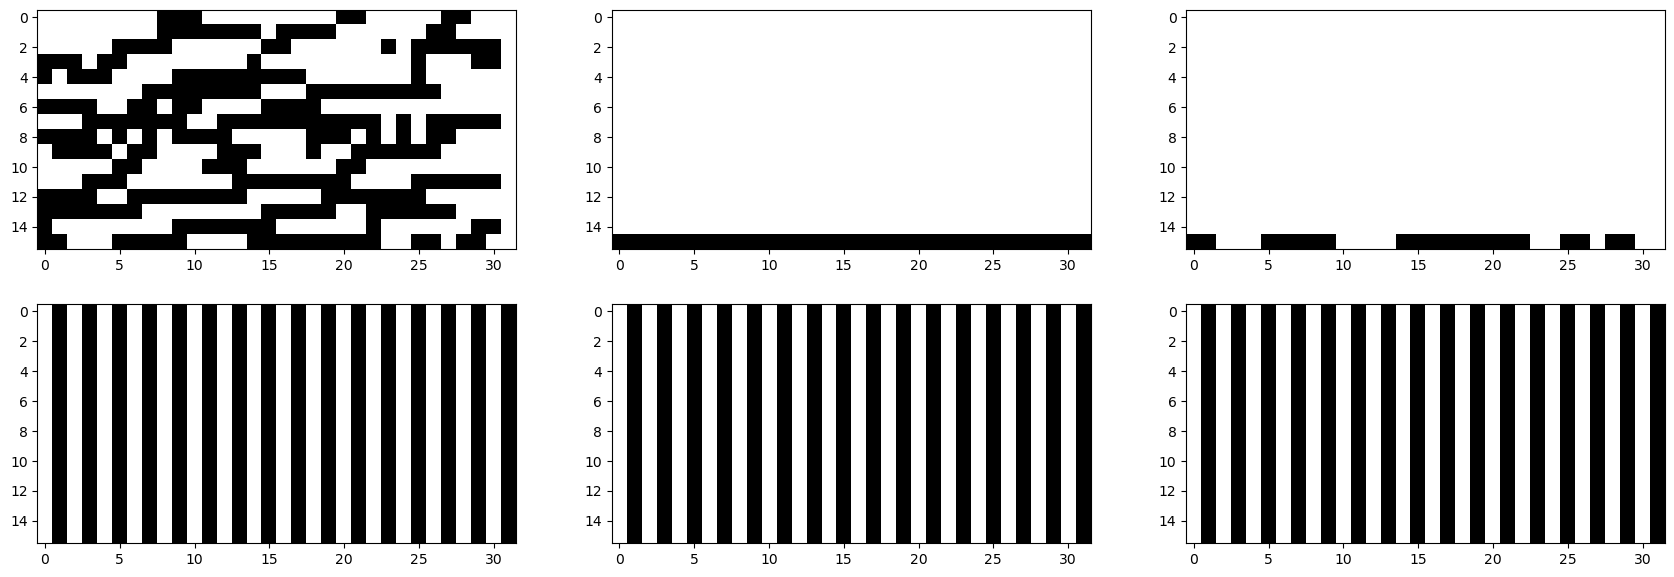

In [71]:
plt.figure(figsize=(21, 7))
plt.subplot(2, 3, 1)
plt.imshow(tgt_h[0], cmap='gray')
plt.subplot(2, 3, 2)
plt.imshow(tgt_w[0], cmap='gray')
plt.subplot(2, 3, 3)
plt.imshow(tgt_mask[0], cmap='gray')
plt.subplot(2, 3, 4)
plt.imshow(pred_h[0], cmap='gray')
plt.subplot(2, 3, 5)
plt.imshow(pred_w[0], cmap='gray')
plt.subplot(2, 3, 6)
plt.imshow(pred_mask[0], cmap='gray')

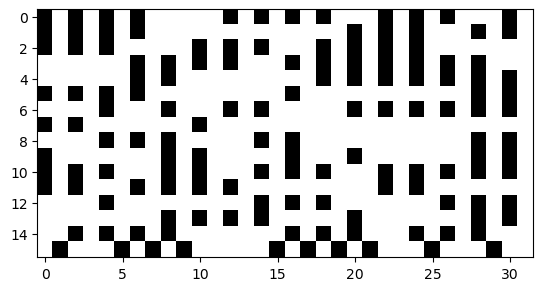

In [72]:
plt.imshow(rev_mask[0], cmap='gray')